# FESTO servo valve — supply characteristic

Supply pressure mapping: upstream = `supply_pressure` (AI ch6), downstream = `pam_valve_pressure` (AI ch1).

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt

ANALYSIS_DIR = Path.cwd()
if not (ANALYSIS_DIR / 'sweep_common.py').exists():
    ANALYSIS_DIR = Path('valve_sweep/analysis')
sys.path.insert(0, str(ANALYSIS_DIR.resolve()))

from sweep_common import (
    add_effective_area, load_config, load_sweep_bag, summarize_steps,
)

In [2]:
# Point this to a rosbag directory or directly to its .mcap file.
BAG_PATH = Path('~/koni_log/sweep_high_20260717_131506').expanduser()
CONFIG_PATH = ANALYSIS_DIR / 'calibration.yaml'

config = load_config(CONFIG_PATH)
samples = load_sweep_bag(BAG_PATH, config)
summary = summarize_steps(samples, config['analysis']['tail_duration_s'])
result = add_effective_area(summary, 'supply', config)
print(f'{len(samples):,} AI samples, {len(result)} voltage steps')

4,800 AI samples, 12 voltage steps


In [3]:
columns = [
    'step_index', 'command_voltage_v', 'sample_count',
    'flow_l_min_anr', 'flow_std_l_min',
    'upstream_pressure_kpa_g', 'downstream_pressure_kpa_g',
    'pressure_ratio', 'flow_factor_phi', 'mass_flow_kg_s',
    'effective_area_mm2', 'flow_direction_ok',
    'valid_pressure_ratio', 'flow_near_full_scale',
]
result[columns].round(6)

,step_index,command_voltage_v,sample_count,flow_l_min_anr,flow_std_l_min,upstream_pressure_kpa_g,downstream_pressure_kpa_g,pressure_ratio,flow_factor_phi,mass_flow_kg_s,effective_area_mm2,flow_direction_ok,valid_pressure_ratio,flow_near_full_scale
0,0,5.6,51,5.839572,0.365515,337.848482,1.026259,0.233054,1.000000,0.000117,0.113049,True,True,False
1,1,5.8,51,6.779639,0.358364,338.959985,1.153417,0.232755,1.000000,0.000136,0.130916,True,True,False
2,2,6.0,51,8.694503,0.360675,338.606940,1.292542,0.233258,1.000000,0.000174,0.168028,True,True,False
3,3,6.2,50,21.853665,0.914135,335.915043,2.918556,0.238413,1.000000,0.000439,0.424938,True,True,False
4,4,6.4,50,49.897917,0.370820,324.554676,19.364732,0.283389,1.000000,0.001001,0.996132,True,True,False
5,5,6.6,50,52.487679,0.528653,297.045716,59.303691,0.403214,0.999986,0.001053,1.120197,True,True,False
6,6,6.8,50,54.804606,0.271225,264.753058,107.110209,0.569374,0.959329,0.001100,1.299514,True,True,False
7,7,7.0,50,56.480656,0.352259,242.134615,133.236706,0.682938,0.881832,0.001133,1.488855,True,True,False
8,8,7.2,51,57.391130,0.353982,229.045662,150.655926,0.762722,0.796577,0.001152,1.654820,True,True,False
9,9,7.4,51,58.052349,0.353876,218.213253,159.027444,0.814777,0.722573,0.001165,1.817095,True,True,False


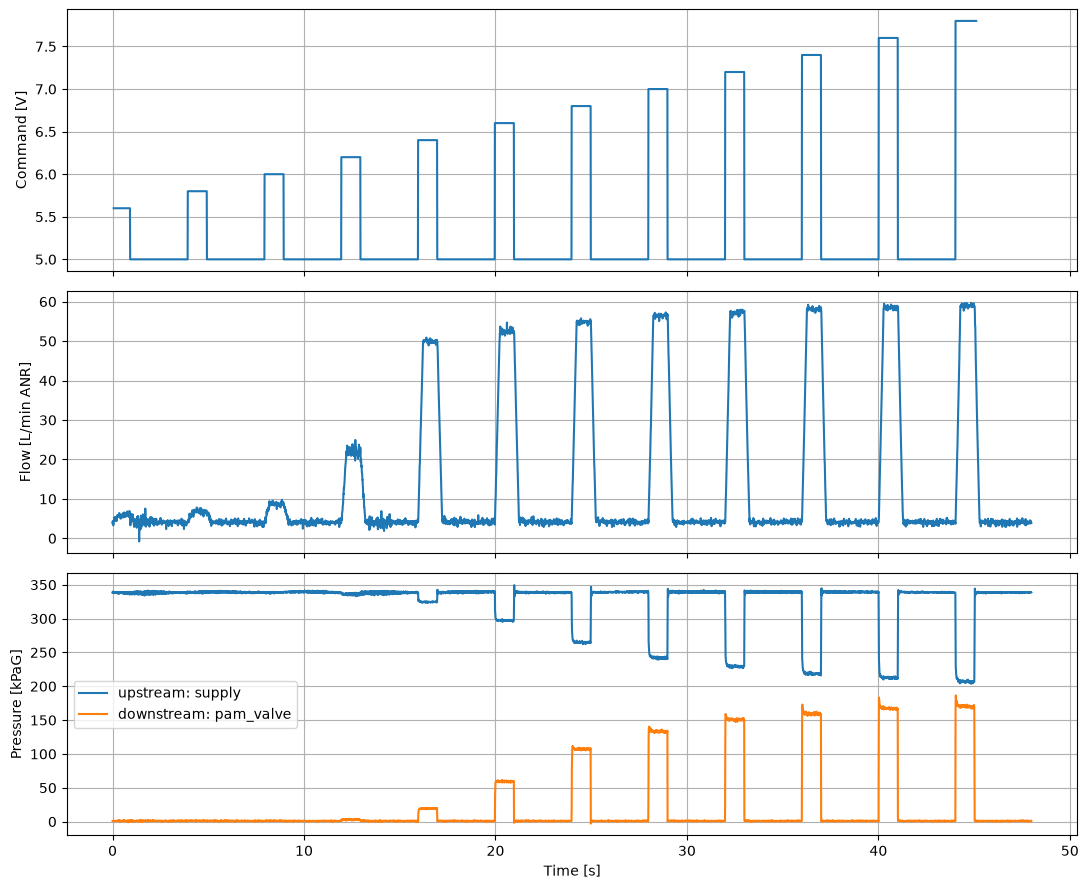

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
axes[0].plot(samples['time_s'], samples['command_voltage_v'])
axes[0].set_ylabel('Command [V]')
axes[1].plot(samples['time_s'], samples['flow_l_min_anr'])
axes[1].set_ylabel('Flow [L/min ANR]')
axes[2].plot(samples['time_s'], samples['supply_pressure_kpa_g'], label='upstream: supply')
axes[2].plot(samples['time_s'], samples['pam_valve_pressure_kpa_g'], label='downstream: pam_valve')
axes[2].set_ylabel('Pressure [kPaG]')
axes[2].set_xlabel('Time [s]')
axes[2].legend()
for axis in axes:
    axis.grid(True)
fig.tight_layout()

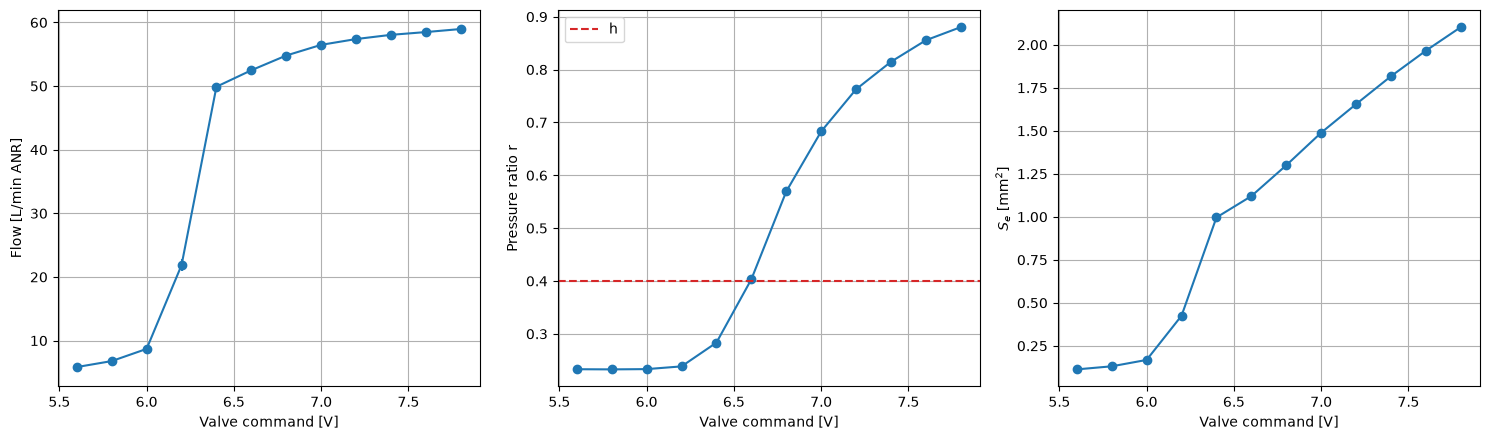

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
axes[0].errorbar(result['command_voltage_v'], result['flow_l_min_anr'], yerr=result['flow_std_l_min'], marker='o')
axes[0].set_ylabel('Flow [L/min ANR]')
axes[1].plot(result['command_voltage_v'], result['pressure_ratio'], marker='o')
axes[1].axhline(config['model']['critical_pressure_ratio'], color='tab:red', linestyle='--', label='h')
axes[1].set_ylabel('Pressure ratio r')
axes[1].legend()
axes[2].plot(result['command_voltage_v'], result['effective_area_mm2'], marker='o')
axes[2].set_ylabel(r'$S_e$ [mm$^2$]')
for axis in axes:
    axis.set_xlabel('Valve command [V]')
    axis.grid(True)
fig.tight_layout()

In [6]:
problems = result.loc[
    (~result['flow_direction_ok'])
    | (~result['valid_pressure_ratio'])
    | result['flow_near_full_scale']
]
if problems.empty:
    print('No direction, pressure-ratio, or flow-range warnings.')
else:
    display(problems[columns])

No direction, pressure-ratio, or flow-range warnings.


In [7]:
# Optional CSV export
# output_path = BAG_PATH.with_name(BAG_PATH.name + '_supply_analysis.csv')
# result.to_csv(output_path, index=False)
# output_path